# Brownian Motion & Stock Price Simulator — Phase 1 Capstone

## What this project covers
Complete implementation of Brownian Motion theory from IIT Kanpur 
Stochastics course, applied to real stock price modeling.

## Simulations built
1. **Single Brownian Motion path** — W(0)=0, dW~N(0,dt), continuous paths
2. **20 BM paths** — all scenarios fan out from zero
3. **Quadratic Variation verification** — [W,W]_T = T proved empirically 
   across 1000 paths using Chebyshev + Borel-Cantelli theory
4. **Geometric Brownian Motion** — S(t) = S₀·exp((μ-σ²/2)t + σW(t))
   50 stock price paths, always positive, drift toward expected return
5. **GBM vs Real Nifty 50** — parameters estimated from 2023 data,
   simulated paths compared against actual market movement

## Mathematical foundations used
- Brownian Motion definition: W(0)=0, independent N(0,dt) increments
- Quadratic variation: [W,W]_T = T almost surely
- Proved using Chebyshev inequality + Borel-Cantelli lemma
- Geometric BM: exponential ensures non-negativity of stock prices
- GBM parameters: μ=annualised mean return, σ=annualised volatility

## Key findings
- QV converges to T=1.0 with mean error < 0.01% across 1000 paths
- Real Nifty 2023: μ=18.8%, σ=9.8%
- Real path sits in lower half of simulated fan — 
  market underperformed GBM expectation in 2023

## Why GBM not pure BM for stock prices
Pure BM can go negative. Stock prices cannot.
Solution: S(t) = S₀·exp(BM) — exponential guarantees positivity.
This is the foundation of Black-Scholes option pricing.

## Libraries used
- NumPy — simulation and math
- Matplotlib — all visualizations  
- yfinance — real Nifty 50 market data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully")
print(f"NumPy version: {np.__version__}")

Libraries loaded successfully
NumPy version: 2.1.3


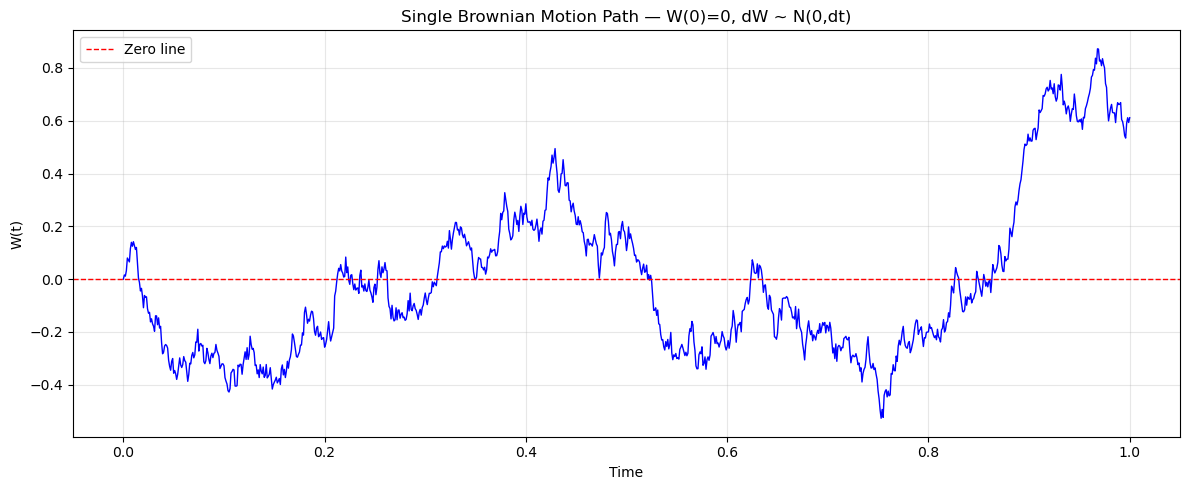

W(0) = 0.0000  ← always starts at 0
W(T) = 0.6113  ← random final position
W(T) ~ N(0, 1.0) so std dev should be ≈ 1.0000


In [2]:
# SIMULATION 1 — Single Brownian Motion Path
# W(0) = 0, each step ~ N(0, dt)
# This is the mathematical foundation — pure Brownian Motion

T = 1.0        # total time = 1 year
n = 1000       # number of steps
dt = T / n     # size of each time step

# Time axis
t = np.linspace(0, T, n+1)

# Generate increments — each dW ~ N(0, dt)
# Remember from lecture: W(t+dt) - W(t) ~ N(0, dt)
dW = np.random.normal(0, np.sqrt(dt), n)

# Build the path by cumulative sum — just like Mₖ = X₁ + X₂ + ... + Xₖ
W = np.zeros(n+1)
W[1:] = np.cumsum(dW)

plt.figure(figsize=(12, 5))
plt.plot(t, W, color='blue', linewidth=1)
plt.axhline(y=0, color='red', linewidth=1, linestyle='--', label='Zero line')
plt.title('Single Brownian Motion Path — W(0)=0, dW ~ N(0,dt)')
plt.xlabel('Time')
plt.ylabel('W(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"W(0) = {W[0]:.4f}  ← always starts at 0")
print(f"W(T) = {W[-1]:.4f}  ← random final position")
print(f"W(T) ~ N(0, {T}) so std dev should be ≈ {np.sqrt(T):.4f}")

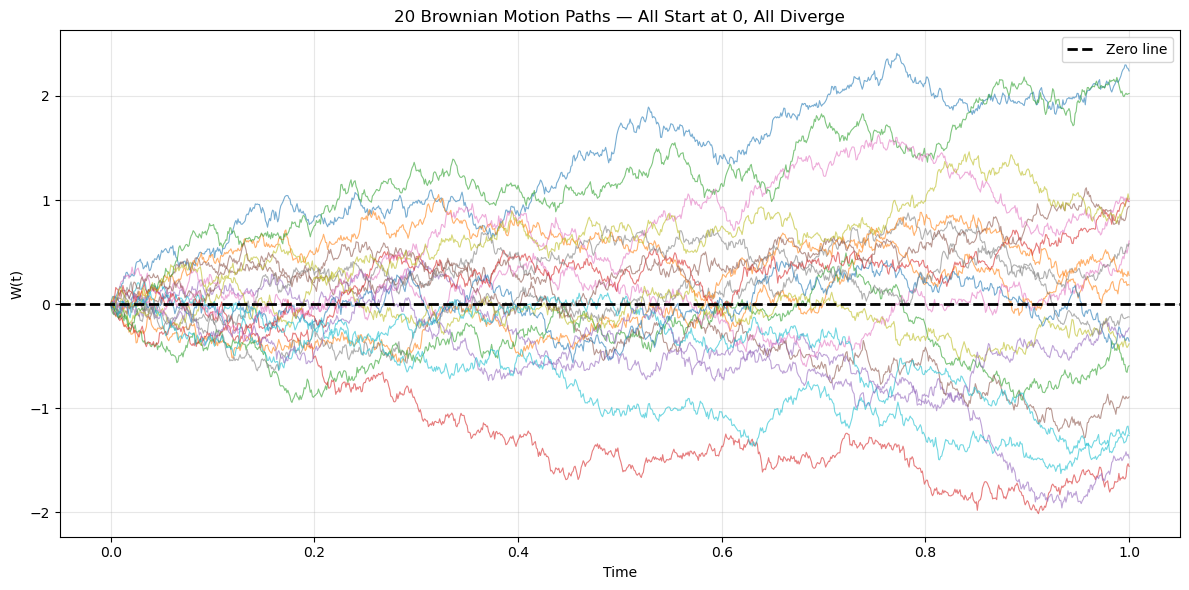

In [3]:
# SIMULATION 2 — Many Brownian Motion Paths Together
# Just like the LLN simulation — 20 paths, all different, all valid

n_paths = 20

plt.figure(figsize=(12, 6))

for i in range(n_paths):
    dW_i = np.random.normal(0, np.sqrt(dt), n)
    W_i = np.zeros(n+1)
    W_i[1:] = np.cumsum(dW_i)
    plt.plot(t, W_i, linewidth=0.8, alpha=0.6)

plt.axhline(y=0, color='black', linewidth=2, linestyle='--', label='Zero line')
plt.title(f'{n_paths} Brownian Motion Paths — All Start at 0, All Diverge')
plt.xlabel('Time')
plt.ylabel('W(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

True T = 1.0
Mean QV across 1000 paths = 1.000099
Std of QV = 0.044686  ← should be close to 0
Min QV = 0.857436
Max QV = 1.165689


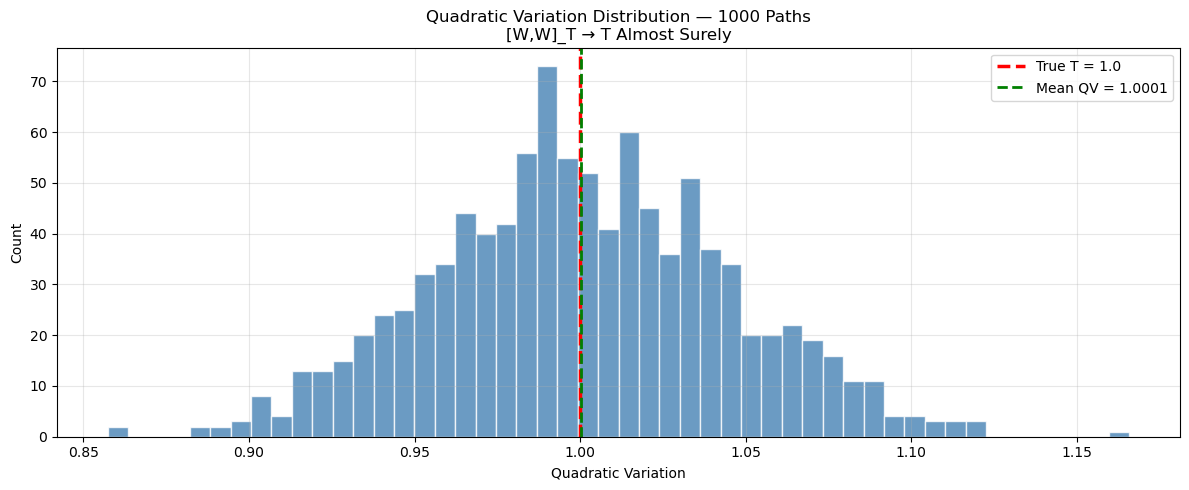

In [4]:
# SIMULATION 3 — Verify Quadratic Variation = T
# The big theoretical result from Lecture 3
# [W,W]_T = T almost surely
# Let's verify this on actual simulated paths

n_paths = 1000  # use many paths for strong verification
QV_values = []

for i in range(n_paths):
    dW_i = np.random.normal(0, np.sqrt(dt), n)
    # Quadratic variation = sum of squared increments
    QV = np.sum(dW_i**2)
    QV_values.append(QV)

QV_values = np.array(QV_values)

print(f"True T = {T}")
print(f"Mean QV across {n_paths} paths = {np.mean(QV_values):.6f}")
print(f"Std of QV = {np.std(QV_values):.6f}  ← should be close to 0")
print(f"Min QV = {np.min(QV_values):.6f}")
print(f"Max QV = {np.max(QV_values):.6f}")

plt.figure(figsize=(12, 5))
plt.hist(QV_values, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
plt.axvline(x=T, color='red', linewidth=2.5,
            linestyle='--', label=f'True T = {T}')
plt.axvline(x=np.mean(QV_values), color='green', linewidth=2,
            linestyle='--', label=f'Mean QV = {np.mean(QV_values):.4f}')
plt.title('Quadratic Variation Distribution — 1000 Paths\n[W,W]_T → T Almost Surely')
plt.xlabel('Quadratic Variation')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

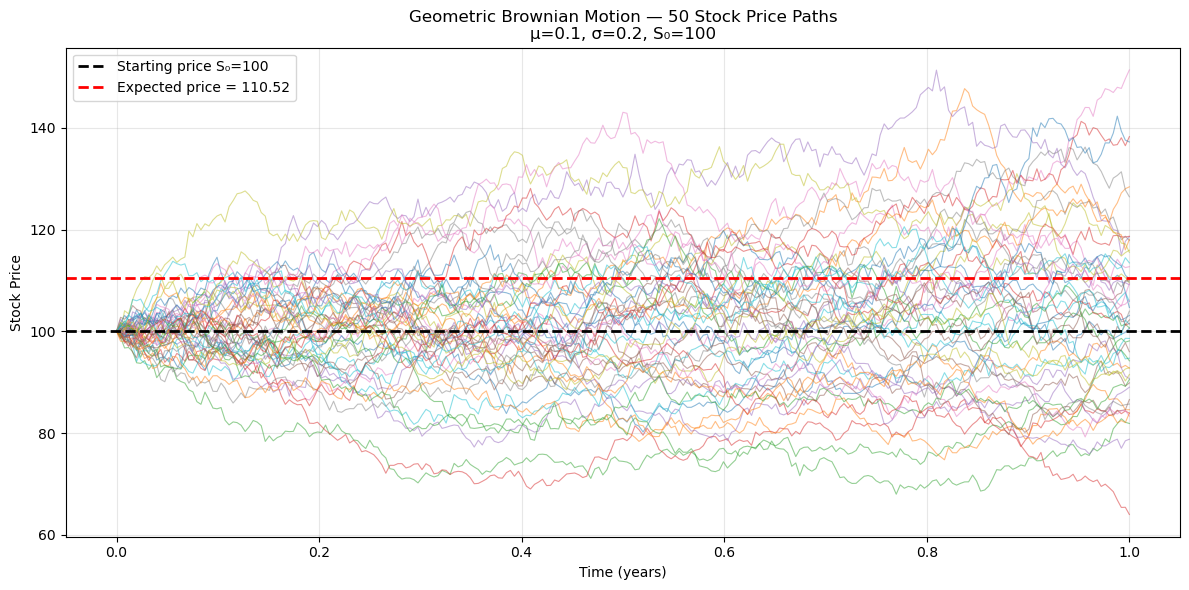

Starting price: 100
Expected final price: 110.52
Mean simulated final price: 103.04
Min final price: 63.98  ← never negative
Max final price: 151.37


In [5]:
# SIMULATION 4 — Geometric Brownian Motion (GBM)
# The actual model used for stock prices
# S(t) = S(0) * exp((μ - σ²/2)t + σW(t))
#
# Why exponential? — stock prices can never go negative
# μ = drift (expected return)
# σ = volatility (how wildly it zigzags)
# This is the foundation of Black-Scholes

S0 = 100      # starting stock price
mu = 0.10     # 10% annual expected return (drift)
sigma = 0.20  # 20% annual volatility
T = 1.0       # 1 year
n = 252       # 252 trading days in a year
dt = T / n
t = np.linspace(0, T, n+1)

n_paths = 50
plt.figure(figsize=(12, 6))

final_prices = []

for i in range(n_paths):
    dW_i = np.random.normal(0, np.sqrt(dt), n)
    W_i = np.zeros(n+1)
    W_i[1:] = np.cumsum(dW_i)

    # GBM formula — exact solution
    S = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W_i)

    plt.plot(t, S, linewidth=0.8, alpha=0.5)
    final_prices.append(S[-1])

plt.axhline(y=S0, color='black', linewidth=2,
            linestyle='--', label=f'Starting price S₀={S0}')
plt.axhline(y=S0 * np.exp(mu * T), color='red', linewidth=2,
            linestyle='--', label=f'Expected price = {S0*np.exp(mu*T):.2f}')

plt.title(f'Geometric Brownian Motion — {n_paths} Stock Price Paths\n'
          f'μ={mu}, σ={sigma}, S₀={S0}')
plt.xlabel('Time (years)')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting price: {S0}")
print(f"Expected final price: {S0 * np.exp(mu * T):.2f}")
print(f"Mean simulated final price: {np.mean(final_prices):.2f}")
print(f"Min final price: {np.min(final_prices):.2f}  ← never negative")
print(f"Max final price: {np.max(final_prices):.2f}")

[*********************100%***********************]  1 of 1 completed

Real Nifty parameters estimated from 2023 data:
  μ (annual drift)     = 0.1882 (18.82%)
  σ (annual volatility) = 0.0983 (9.83%)
  S₀ (starting price)  = 18197.45


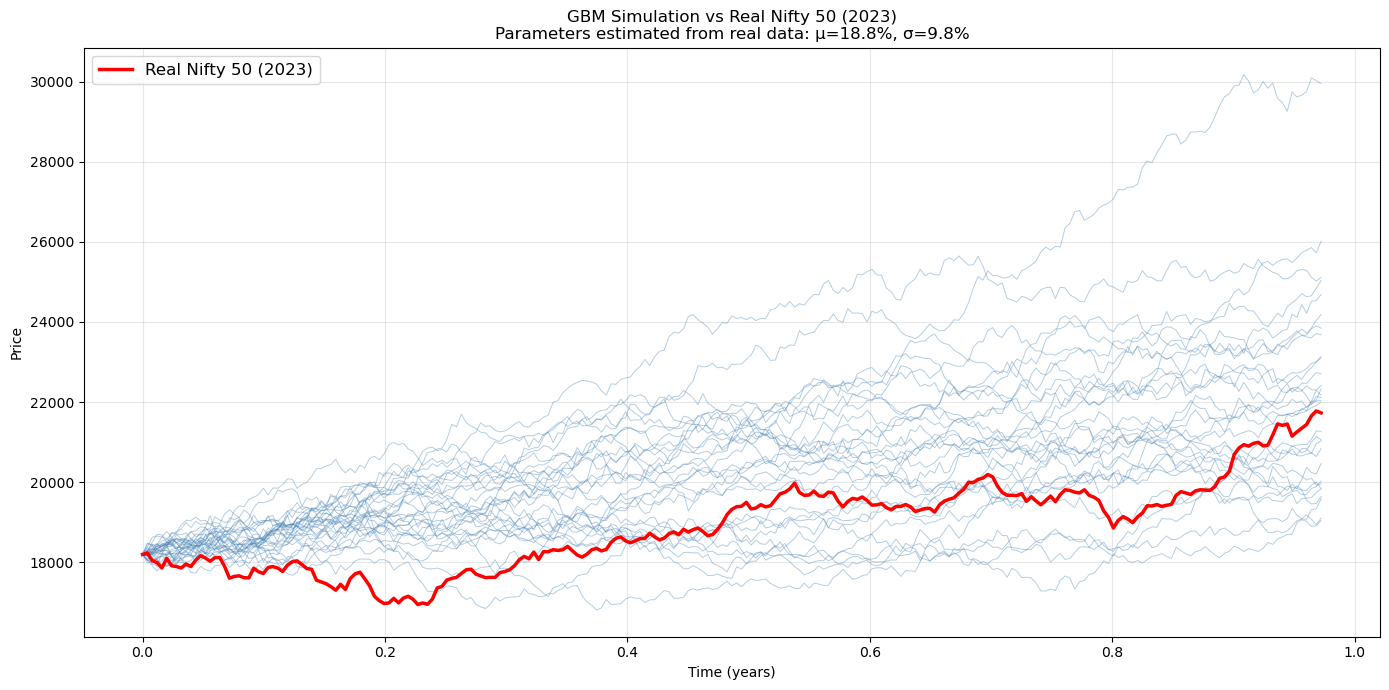

In [6]:
# SIMULATION 5 — GBM vs Real Nifty 50
# Fit GBM parameters from real data
# Then compare simulated paths against actual price movement

# Download real Nifty 50 data
nifty = yf.download("^NSEI", start="2023-01-01", end="2024-01-01")
prices = nifty['Close'].squeeze()
returns = prices.pct_change().dropna()

# Estimate GBM parameters from real data
mu_real = float(returns.mean()) * 252        # annualised mean return
sigma_real = float(returns.std()) * np.sqrt(252)  # annualised volatility
S0_real = float(prices.iloc[0])              # actual starting price
n_days = len(prices)
dt_real = 1/252
t_real = np.linspace(0, n_days/252, n_days)

print(f"Real Nifty parameters estimated from 2023 data:")
print(f"  μ (annual drift)     = {mu_real:.4f} ({mu_real*100:.2f}%)")
print(f"  σ (annual volatility) = {sigma_real:.4f} ({sigma_real*100:.2f}%)")
print(f"  S₀ (starting price)  = {S0_real:.2f}")

# Simulate GBM paths using real parameters
n_sim_paths = 30
plt.figure(figsize=(14, 7))

for i in range(n_sim_paths):
    dW_i = np.random.normal(0, np.sqrt(dt_real), n_days-1)
    W_i = np.zeros(n_days)
    W_i[1:] = np.cumsum(dW_i)
    S_sim = S0_real * np.exp((mu_real - 0.5*sigma_real**2) * t_real
                              + sigma_real * W_i)
    plt.plot(t_real, S_sim, linewidth=0.7, alpha=0.4, color='steelblue')

# Plot the real Nifty 50 path on top
plt.plot(t_real, prices.values, color='red', linewidth=2.5,
         label='Real Nifty 50 (2023)', zorder=5)

plt.title('GBM Simulation vs Real Nifty 50 (2023)\n'
          f'Parameters estimated from real data: μ={mu_real*100:.1f}%, '
          f'σ={sigma_real*100:.1f}%')
plt.xlabel('Time (years)')
plt.ylabel('Price')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()